# Лабораторная работа № 1
## Сбор, визуализация и анализ данных по графу

**Тема: графовые методы в рекомендательных системах.**

Цель работы - собрать статьи, выделить ключевые слова, исследовать связи
между ними и находить похожие публикации по общим ключевым словам.

In [20]:
# %pip install numpy pandas matplotlib scikit-learn networkx nltk

In [21]:
from collections import Counter
from itertools import combinations
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import re
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 11, 'axes.unicode_minus': False})
pd.set_option('display.max_colwidth', 110)

## 1. Выбор тематики

Исследую **графовые методы в рекомендательных системах**: использование графов
взаимодействий пользователей с объектами, графов знаний и графовых нейросетей.

## 2. Сбор публикаций через API arXiv

Сохраняю идентификатор, название, авторов, аннотацию, дату первой публикации и ссылку.

In [22]:
QUERY = (
    'ti:graph AND (ti:recommendation OR ti:recommender) '
    'AND submittedDate:[202001010000 TO 202610042359]'
)
N_PAPERS = 400
DATA_PATH = Path('papers.csv')


def parse_arxiv(xml_data):
    ns = {'atom': 'http://www.w3.org/2005/Atom'}
    root = ET.fromstring(xml_data)
    rows = []
    for entry in root.findall('atom:entry', ns):
        entry_id = entry.findtext('atom:id', default='', namespaces=ns)
        if '/abs/' not in entry_id:
            raise ValueError('API arXiv вернул сообщение об ошибке вместо статьи')
        paper_id = re.sub(r'v\d+$', '', entry_id.split('/abs/')[-1])
        rows.append({
            'arxiv_id': paper_id,
            'title': ' '.join(entry.findtext('atom:title', default='', namespaces=ns).split()),
            'authors': '; '.join(author.findtext('atom:name', default='', namespaces=ns)
                                 for author in entry.findall('atom:author', ns)),
            'abstract': ' '.join(entry.findtext('atom:summary', default='', namespaces=ns).split()),
            'published': entry.findtext('atom:published', default='', namespaces=ns),
            'url': 'https://arxiv.org/abs/' + paper_id,
        })
    return pd.DataFrame(rows)


def download_papers():
    params = urlencode({
        'search_query': QUERY, 'start': 0, 'max_results': N_PAPERS,
        'sortBy': 'submittedDate', 'sortOrder': 'descending',
    })
    request = Request('https://export.arxiv.org/api/query?' + params,
                      headers={'User-Agent': 'GraphRecommendationsStudentLab/1.0'})
    with urlopen(request, timeout=90) as response:
        return parse_arxiv(response.read())

In [23]:
if DATA_PATH.exists():
    raw = pd.read_csv(DATA_PATH, dtype={'arxiv_id': str})
    print('Источник: сохранённая выгрузка API arXiv,', DATA_PATH)
else:
    raw = download_papers()
    raw.to_csv(DATA_PATH, index=False)
    print('Источник: API arXiv; выгрузка сохранена в', DATA_PATH)

print('Запрос:', QUERY)
required = ['arxiv_id', 'title', 'authors', 'abstract', 'published']
display(pd.DataFrame({'Пропуски': raw[required].isna().sum()}))
print('Повторяющихся ID:', raw['arxiv_id'].duplicated().sum())

df = raw.dropna(subset=required).copy()
for column in ['arxiv_id', 'title', 'authors', 'abstract']:
    df = df[df[column].str.strip().ne('')]
df['published'] = pd.to_datetime(df['published'], utc=True, errors='coerce')
df = df[df['published'].between('2020-01-01', '2026-10-04 23:59:59+00:00')]
df = df.drop_duplicates('arxiv_id').reset_index(drop=True)
assert len(df) >= 300, 'После очистки должно остаться не менее 300 статей'
assert df['arxiv_id'].is_unique
print(f'После очистки: {len(df)} статей; исключено: {len(raw) - len(df)}.')
display(df[['arxiv_id', 'title', 'authors', 'published']].head(5))

Источник: API arXiv; выгрузка сохранена в papers.csv
Запрос: ti:graph AND (ti:recommendation OR ti:recommender) AND submittedDate:[202001010000 TO 202610042359]


,Пропуски
arxiv_id,0
title,0
authors,0
abstract,0
published,0


Повторяющихся ID: 0
После очистки: 400 статей; исключено: 0.


,arxiv_id,title,authors,published
0,2609.31253,Enriching Sequential Recommendation with Graph Laplacian Positional Embeddings,Ekaterina Trushkova; Artur Gimranov; Anton Lysenko,2026-09-25 13:27:23+00:00
1,2610.00212,EviGraph: Proof-Carrying Selective Recommendation over Temporal Public-Service Knowledge Graphs,Yixi Zhou; Sikun Wang; Lei Fan; Fan Zhang,2026-09-21 13:26:48+00:00
2,2609.15692,Complete Suffix Prediction for Recommendation via Latent Retrieval over Process Graphs,Sarra Madad; Myriam Maumy; Fr{é}d{é}ric Bertrand; Yoann Valero,2026-09-14 14:59:08+00:00
3,2609.05909,Do All Nodes Benefit Equally from Knowledge Graphs? Adaptive Node-Aware KG Fusion for Recommendation,Jaehyun Park; Minseo Jeon; Daewon Gwak; Sunuk Kim; Hanvit Lee; Jinhong Jung,2026-09-05 06:03:02+00:00
4,2609.04862,Personalized Task Dependency Graphs for Mitigating Signal Erosion in Multi-Task Recommendation,Fuyuan Liu; Tiandeng Wu; Yaqun Fang; Wei Zhou; Zehao Zhou; Wenping Chen; Qishun Mei; Jiaxin Zhou; Heng Cha...,2026-09-04 08:23:12+00:00


## 3. Разведочный анализ, законы Ципфа и Хипса

Смотрим на даты публикаций, длины аннотаций и частоты слов.
Для закона Ципфа беру названия и аннотации.

По закону Ципфа частота слова приблизительно обратно пропорциональна его рангу. На графике с логарифмическими осями ожидается участок,
близкий к прямой с наклоном -1.

,Слов в аннотации
count,400.0
mean,198.0
std,44.0
min,88.0
25%,166.0
50%,200.0
75%,232.0
max,288.0


Первая дата: 2023-05-22
Последняя дата: 2026-09-25


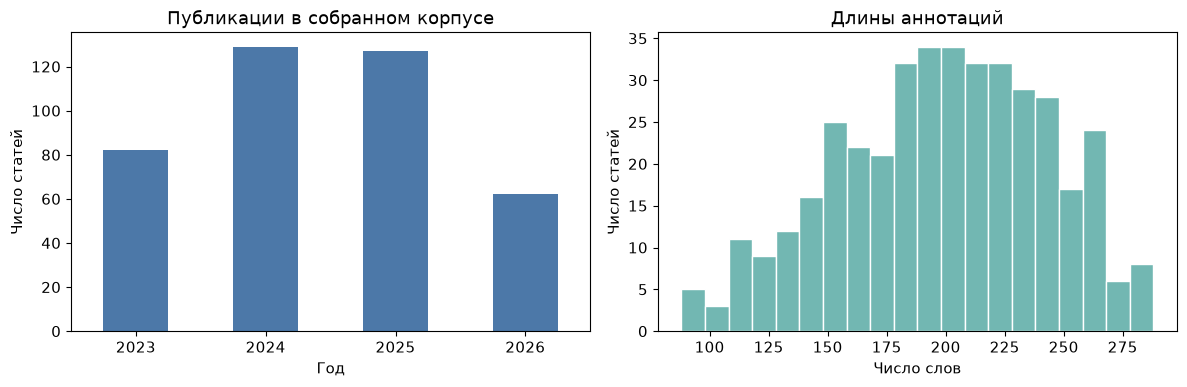

In [24]:
df['year'] = df['published'].dt.year
df['abstract_words'] = df['abstract'].str.findall(r'[A-Za-z]+').str.len()
display(df['abstract_words'].describe().round(1).to_frame('Слов в аннотации'))
print('Первая дата:', df['published'].min().date())
print('Последняя дата:', df['published'].max().date())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['year'].value_counts().sort_index().plot.bar(ax=axes[0], color='#4c78a8', rot=0)
axes[0].set(title='Публикации в собранном корпусе', xlabel='Год', ylabel='Число статей')
axes[1].hist(df['abstract_words'], bins=20, color='#72b7b2', edgecolor='white')
axes[1].set(title='Длины аннотаций', xlabel='Число слов', ylabel='Число статей')
plt.tight_layout()
plt.show()

Всего слов: 83,618; различных словоформ: 5,756
Наклон на рангах 10-500: -0.906; ориентир Ципфа: -1.


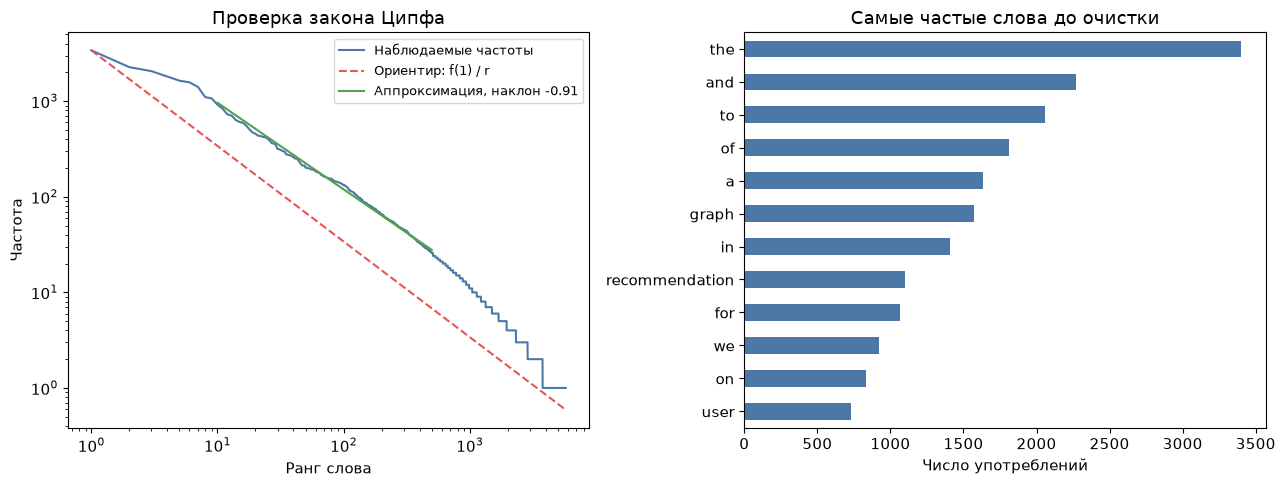

In [25]:
texts = df['title'] + ' ' + df['abstract']
all_words = re.findall(r'[a-z]+', ' '.join(texts).lower())
frequencies = Counter(all_words)
counts = np.array(sorted(frequencies.values(), reverse=True))
ranks = np.arange(1, len(counts) + 1)

# Средние ранги: меньше влияния первых слов и редкого «хвоста».
fit_mask = (ranks >= 10) & (ranks <= 500)
slope, intercept = np.polyfit(np.log(ranks[fit_mask]), np.log(counts[fit_mask]), 1)
print(f'Всего слов: {len(all_words):,}; различных словоформ: {len(frequencies):,}')
print(f'Наклон на рангах 10-500: {slope:.3f}; ориентир Ципфа: -1.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].loglog(ranks, counts, label='Наблюдаемые частоты', color='#4c78a8')
axes[0].loglog(ranks, counts[0] / ranks, '--', label='Ориентир: f(1) / r', color='#e45756')
axes[0].loglog(ranks[fit_mask], np.exp(intercept) * ranks[fit_mask] ** slope,
               label=f'Аппроксимация, наклон {slope:.2f}', color='#54a24b')
axes[0].set(title='Проверка закона Ципфа', xlabel='Ранг слова', ylabel='Частота')
axes[0].legend(fontsize=9)
pd.Series(dict(frequencies.most_common(12))).sort_values().plot.barh(ax=axes[1], color='#4c78a8')
axes[1].set(title='Самые частые слова до очистки', xlabel='Число употреблений', ylabel='')
plt.tight_layout()
plt.show()

В выгрузке 400 уникальных статей. Даты - от 22.05.2023 до 25.09.2026, работы актуальные по дате. По годам: 82 статьи за 2023 год,
129 за 2024, 127 за 2025 и 62 за 2026. Я ограничила выдачу 400 свежими статьями,
поэтому отсутствие 2020-2022 годов и меньшие числа по крайним годам не означают
отсутствие исследований или спад интереса к теме.

Средняя длина аннотации - 198 слов, медиана - 200; половина аннотаций содержит
от 166 до 232 слов. Минимальная и максимальная длины - 88 и 288 слов.
Названия и аннотации вместе содержат 83 618 словоупотреблений и 5756 словоформ.

Наклон частотной кривой на рангах 10-500 равен **-0,906**, что близко к -1:
на этом участке распределение согласуется с приближённой закономерностью Ципфа.
Первые слова и редкий «хвост» отклоняются от прямой, единичные частоты дают ступеньки.
Красная линия задаёт ориентир с масштабом по самому частому слову.
Частые `the`, `and`, `to` показывают, зачем перед выделением ключевых слов нужно удалять стоп-слова.

### Проверка закона Хипса

Закон Хипса описывает рост словаря при увеличении объёма текста:
$V(N) \approx K N^{\beta}$, где $N$ - число словоупотреблений,
$V(N)$ - число различных слов, а $K$ и $\beta$ - параметры.
При $0 < \beta < 1$ словарь растёт медленнее общего числа слов.

Берём ту же последовательность `all_words`, что и для Ципфа: названия и аннотации
в порядке статей в CSV, нижний регистр, без удаления стоп-слов и стемминга.
Начиная с 1000 слов фиксируем размер накопленного словаря через каждые 1000 слов
и в конце корпуса. Оцениваем параметры линейной аппроксимацией
$\log V = \log K + \beta \log N$. $R^2$ считаем в этих же логарифмических координатах.


N = 83,618; V = 5,756
K = 20.126; beta = 0.502; R² в log-log = 0.989


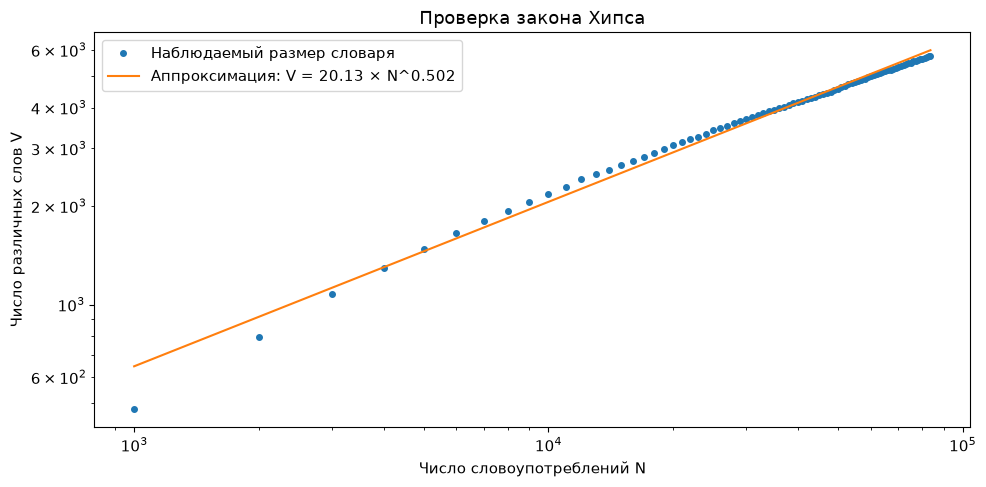

In [26]:
seen_words = set()
token_counts = []
vocabulary_sizes = []
for number, word in enumerate(all_words, start=1):
    seen_words.add(word)
    if number % 1000 == 0 or number == len(all_words):
        token_counts.append(number)
        vocabulary_sizes.append(len(seen_words))

token_counts = np.array(token_counts)
vocabulary_sizes = np.array(vocabulary_sizes)
heaps_beta, heaps_log_k = np.polyfit(np.log(token_counts), np.log(vocabulary_sizes), 1)
heaps_k = np.exp(heaps_log_k)
heaps_prediction = heaps_k * token_counts ** heaps_beta
log_vocabulary = np.log(vocabulary_sizes)
heaps_r2_log = 1 - np.sum((log_vocabulary - np.log(heaps_prediction)) ** 2) / np.sum(
    (log_vocabulary - log_vocabulary.mean()) ** 2
)

print(f'N = {token_counts[-1]:,}; V = {vocabulary_sizes[-1]:,}')
print(f'K = {heaps_k:.3f}; beta = {heaps_beta:.3f}; R² в log-log = {heaps_r2_log:.3f}')

plt.figure(figsize=(10, 5))
plt.loglog(token_counts, vocabulary_sizes, 'o', markersize=4, label='Наблюдаемый размер словаря')
plt.loglog(token_counts, heaps_prediction, '-',
           label=f'Аппроксимация: V = {heaps_k:.2f} × N^{heaps_beta:.3f}')
plt.title('Проверка закона Хипса')
plt.xlabel('Число словоупотреблений N')
plt.ylabel('Число различных слов V')
plt.legend()
plt.tight_layout()
plt.show()

Для 84 накопленных префиксов получено
$V(N) \approx 20{,}126 \cdot N^{0{,}502}$, $R^2_{\log} \approx 0{,}989$.
В конце корпуса 83 618 словоупотреблений и 5756 различных словоформ.

Показатель $\beta \approx 0{,}502$ находится между 0 и 1: при увеличении текста
новые слова продолжают появляться, но словарь растёт медленнее числа словоупотреблений.
Например, по оценённой формуле удвоение объёма соответствует росту словаря
приблизительно в $2^{0{,}502} \approx 1{,}42$ раза.
Близость точек к прямой на графике и высокое $R^2_{\log}$ согласуются
с приближённой степенной зависимостью на данном корпусе.

## 4. Выделение ключевых слов

**Очистка LaTeX.** Перед токенизацией для TF-IDF снимаем команды
форматирования `\textbf`, `\textit`, `\emph`, `\underline`, сохраняя их содержимое.
Затем убираем фигурные скобки группировки и знаки `$`.
Имена остальных команд заменяем пробелами. Математические формулы не интерпретируем.
Так служебная разметка не становится тегом и не создаёт связи между статьями.

Для каждого текста выполняем очистку, приведение к нижнему регистру, удаление
английских стоп-слов и стемминг Snowball. Стемминг приводит разные словоформы
к общей основе, например `patterns -> pattern`.

**Стоп-слова.** Основа - готовый английский список `ENGLISH_STOP_WORDS`
из scikit-learn. К нему вручную добавлен фиксированный набор `extra_stop_words`: `paper`, `propose`, `proposed`, `study`, `results`,
`result`, `experiments`, `experimental`, `approach`, `method`.
Это общие слова научных аннотаций о статье, методе, результатах и экспериментах,
они слабо различают темы исследований. Набор одинаков для всех публикаций. Проверка по списку выполняется после приведения
к нижнему регистру, до стемминга, по точному совпадению слова.

TF-IDF повышает вес терминов, которые важны для данной статьи и встречаются в меньшей доле корпуса. Используем униграммы и биграммы после нормализации.
`min_df=3` исключает термины, встретившиеся менее чем в трёх текстах;
`max_df=0.8` исключает термины более чем из 80% текстов. 
Сначала выбираем семь терминов с наибольшим TF-IDF. Затем удаляем
униграммы, которые уже входят в выбранные биграммы. Освободившиеся места
не заполняем менее весомыми терминами, поэтому итоговый список содержит
до семи тегов. Это уменьшает повторный учёт одного понятия при поиске.
**Сокращения.** Фиксированный словарь `acronym_forms` объединяет
`LLM/LLMs -> llm`, `GNN/GNNs -> gnn`, `KG/KGs -> kg`. После приведения к нижнему
регистру эти замены применяются до фильтра длины и стемминга. Остальные слова проходят обычную обработку.


In [ ]:
stemmer = SnowballStemmer('english')
extra_stop_words = {
    'paper', 'propose', 'proposed', 'study', 'results', 'result',
    'experiments', 'experimental', 'approach', 'method',
}
stop_words = set(ENGLISH_STOP_WORDS) | extra_stop_words

acronym_forms = {
    'llm': 'llm', 'llms': 'llm',
    'gnn': 'gnn', 'gnns': 'gnn',
    'kg': 'kg', 'kgs': 'kg',
}


def normalize(text):
    text = re.sub(r'\\(?:textbf|textit|emph|underline)\*?\s*(?=\{)', '', text)
    text = re.sub(r'\\[A-Za-z]+\*?', ' ', text)
    text = text.translate(str.maketrans('', '', '{}$'))
    normalized_words = []
    for word in re.findall(r'[a-z]+', text.lower()):
        if word in acronym_forms:
            normalized_words.append(acronym_forms[word])
        elif len(word) > 2 and word not in stop_words:
            normalized_words.append(stemmer.stem(word))
    return ' '.join(normalized_words)


def remove_nested_unigrams(keywords):
    phrase_words = {word for phrase in keywords if ' ' in phrase for word in phrase.split()}
    return [term for term in keywords if ' ' in term or term not in phrase_words]


normalized_texts = texts.map(normalize)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.8)
tfidf = vectorizer.fit_transform(normalized_texts)
terms = vectorizer.get_feature_names_out()
TOP_KEYWORDS = 7

keywords = []
for row in tfidf:
    best = np.argsort(-row.data, kind='stable')[:TOP_KEYWORDS]
    selected = terms[row.indices[best]].tolist()
    keywords.append(remove_nested_unigrams(selected))
df['keywords'] = keywords
assert df['keywords'].map(len).gt(0).all(), 'Статья осталась без ключевых слов'
print('Тегов на статью после удаления вложений:',
      df['keywords'].map(len).min(), '-', df['keywords'].map(len).max())
print('Размер словаря TF-IDF:', len(terms))
print('Число выбранных уникальных терминов:', len(set(term for words in keywords for term in words)))
display(df[['title', 'keywords']].head(8))

Тегов на статью после удаления вложений: 3 - 7
Размер словаря TF-IDF: 3615
Число выбранных уникальных терминов: 1130


,title,keywords
0,Enriching Sequential Recommendation with Graph Laplacian Positional Embeddings,"[posit, laplacian, sequenti recommend, replac, embed, deriv]"
1,EviGraph: Proof-Carrying Selective Recommendation over Temporal Public-Service Knowledge Graphs,"[decis, servic, evid, requir, establish, public, support]"
2,Complete Suffix Prediction for Recommendation via Latent Retrieval over Process Graphs,"[latent, complet, retriev process, predict, spectral]"
3,Do All Nodes Benefit Equally from Knowledge Graphs? Adaptive Node-Aware KG Fusion for Recommendation,"[node, item knowledg, adapt, signal, awar kg]"
4,Personalized Task Dependency Graphs for Mitigating Signal Erosion in Multi-Task Recommendation,"[convers, depend, mask, causal, object, multi task]"
5,Continual Graph Memory for Adaptive Recommendation under Intent Drift,"[memori, rec, adapt, occur, continu graph, intent, failur]"
6,Scaling Graph Neural Networks for Friend Recommendation: Multi-Hash User Embeddings and Temporal Neighbor ...,"[friend, tempor, percent, product, sampl, multi, tabl]"
7,Adapting Knowledge Graphs for Behavior Denoising in Sequential Recommendation,"[sequenti recommend, kg, evid, denois, calibr, interact]"


## 5. Граф ключевых слов

Вершина - один уникальный тег. Ребро соединяет два тега, если они выбраны для одной статьи. Вес ребра - число статей, в которых выбраны оба термина.


In [28]:
def keyword_graph(keyword_lists):
    graph = nx.Graph()
    for keywords in keyword_lists:
        unique = sorted(set(keywords))
        graph.add_nodes_from(unique)
        for left, right in combinations(unique, 2):
            weight = graph.get_edge_data(left, right, {}).get("weight", 0)
            graph.add_edge(left, right, weight=weight + 1)
    return graph

In [29]:
G_keywords = keyword_graph(df['keywords'])
print('Вершин:', G_keywords.number_of_nodes())
print('Рёбер:', G_keywords.number_of_edges())
print('Компонент связности:', nx.number_connected_components(G_keywords))
print(f'Плотность: {nx.density(G_keywords):.4f}')

Вершин: 1130
Рёбер: 5164
Компонент связности: 1
Плотность: 0.0081


## 6. Кластеры ключевых слов

Используем жадную максимизацию модулярности.
Алгоритм объединяет сообщества, пока это улучшает модулярность.
Модулярность $Q$ сравнивает долю связей внутри сообществ с ожидаемой долей
в случайном графе с теми же взвешенными степенями. При расчёте учитываем веса рёбер.

In [30]:
communities = list(nx.community.greedy_modularity_communities(G_keywords, weight='weight'))
modularity = nx.community.modularity(G_keywords, communities, weight='weight')
community_id = {term: number for number, group in enumerate(communities, start=1) for term in group}

cluster_rows = []
for number, group in enumerate(communities, start=1):
    top_terms = sorted(group, key=lambda term: (-G_keywords.degree(term, weight='weight'), term))[:8]
    cluster_rows.append({'Кластер': number, 'Терминов': len(group), 'Характерные термины': ', '.join(top_terms)})
clusters = pd.DataFrame(cluster_rows)
print(f'Число кластеров: {len(communities)}; модулярность Q = {modularity:.3f}')
display(clusters)

Число кластеров: 12; модулярность Q = 0.521


,Кластер,Терминов,Характерные термины
0,1,173,"llm, kg, retriev, gnn, knowledg, explan, explain, recommend system"
1,2,170,"contrast learn, node, multimod, privaci, cold start, user item, sequenti, augment"
2,3,152,"embed, diffus, session base, base recommend, scalabl, causal, social recommend, dynam"
3,4,132,"knowledg graph, modal, cross, oper, graph base, rate, context, social"
4,5,126,"user, multi behavior, layer, graph transform, behavior recommend, self supervis, aggreg, prefer"
5,6,115,"sequenti recommend, spectral, graph filter, scale, comput, support, evid, filter"
6,7,113,"item, multimod recommend, poi recommend, text, local, keyphras, structur, feder recommend"
7,8,96,"rec, product, behavior, larg scale, cross domain, intent, domain recommend, patient"
8,9,19,"box, english, ontolog, concept, semant similar, auc, domain specif, high qualiti"
9,10,15,"evalu, cultur, downstream, food, qwen, recip, restrict, substitut"


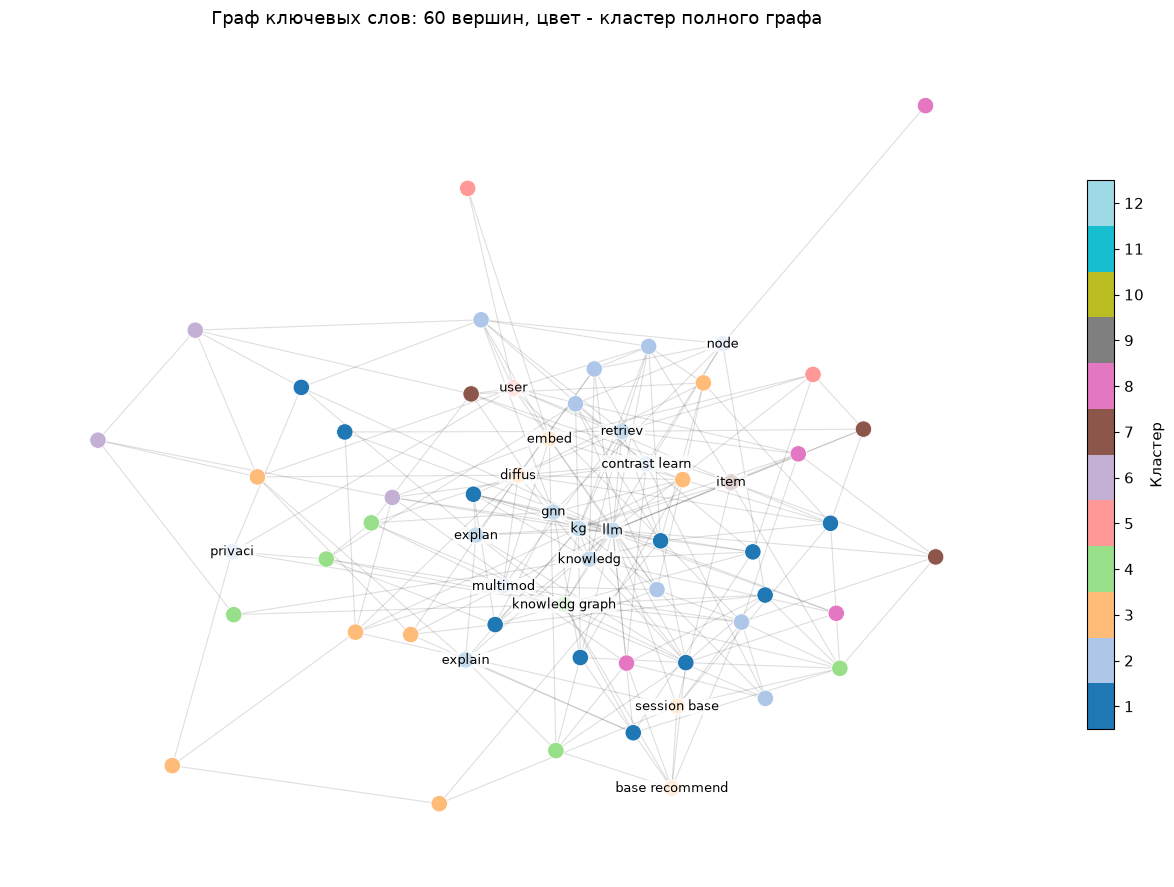

In [ ]:
# Для читаемости рисую 60 наиболее связанных терминов; расчёты сделаны на полном графе.
visible = sorted(G_keywords, key=lambda term: (-G_keywords.degree(term), term))[:60]
view = G_keywords.subgraph(visible)
positions = nx.spring_layout(view, seed=42, k=0.6, iterations=100)
colors = [community_id[term] for term in view]
labels = {term: term for term in visible[:18]}

plt.figure(figsize=(13, 9))
nx.draw_networkx_edges(view, positions, alpha=0.13, width=0.8)
nodes = nx.draw_networkx_nodes(view, positions, node_color=colors,
                       cmap=plt.get_cmap('tab20', len(communities)),
                       vmin=0.5, vmax=len(communities) + 0.5,
                       node_size=140, edgecolors='white', linewidths=0.6)
nx.draw_networkx_labels(view, positions, labels=labels, font_size=9,
                        bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none', 'pad': 1})
plt.colorbar(nodes, ax=plt.gca(), ticks=range(1, len(communities) + 1), label='Кластер', shrink=0.65)
plt.title('Граф ключевых слов: 60 вершин, цвет - кластер полного графа')
plt.axis('off')
plt.tight_layout()
plt.show()

После очистки LaTeX, нормализации сокращений и удаления
вложенных тегов в полном графе 1130 терминов и 5164 ребра. Все вершины входят
в одну компоненту. Найдено 12 кластеров, модулярность **Q = 0,521**.
Первые восемь кластеров содержат от 96 до 173 терминов, последние четыре -
19, 15, 10 и 9 терминов. Модулярность показывает группировку связей,
а смысл групп оцениваем по их словам.

| Кластер | Интерпретация и причина совместного появления слов |
|---|---|
| 1 | **Знания, поиск и объяснение рекомендаций.** `llm`, `kg`, `retriev`, `gnn`, `explan`, `explain`. Эти слова связаны с тем, как модели находят информацию, используют знания и объясняют рекомендации. |
| 2 | **Обучение при ограничениях данных.** `contrast learn`, `node`, `multimod`, `privaci`, `cold start`, `augment`. Здесь собраны разные темы: обучение на разных видах данных, дополнение данных, приватность и рекомендации новым пользователям или объектам. |
| 3 | **Рекомендации с учётом действий и связей.** `embed`, `diffus`, `session base`, `causal`, `social recommend`, `dynam`. Методы представления данных соседствуют с рекомендациями по текущим действиям пользователя и социальным связям. Единой узкой темы нет. |
| 4 | **Контекст рекомендации.** `knowledg graph`, `modal`, `graph base`, `context`, `social`. Эти слова описывают дополнительные сведения и связи, которые помогают подобрать рекомендацию. |
| 5 | **Разные действия пользователя.** `user`, `multi behavior`, `behavior recommend`, `aggreg`, `prefer`, `self supervis`. Действия пользователя объединяют, чтобы обучить модель и определить его предпочтения. |
| 6 | **Последовательность действий и обработка графов.** `sequenti recommend`, `spectral`, `graph filter`, `scale`, `comput`. Группа связывает рекомендации по порядку действий пользователя с обработкой графов и затратами на вычисления. |
| 7 | **Описания объектов и рекомендации мест.** `item`, `multimod recommend`, `poi recommend`, `text`, `keyphras`, `structur`. Здесь смешаны несколько тем: признаки объектов, текстовые описания и подбор мест. |
| 8 | **Поведение и намерения в разных областях.** `product`, `behavior`, `cross domain`, `intent`, `domain recommend`, `patient`. Общая тема — использование поведения и намерений для рекомендаций в разных областях, включая товары и медицину. |
| 9 | **Сходство понятий по смыслу.** `ontolog`, `concept`, `semant similar`, `domain specif`, `english`. Слова связаны с описанием и сравнением понятий. Не все термины однозначно укладываются в эту тему. |
| 10 | **Еда и рецепты.** `food`, `recip`, `substitut`, `cultur`, `qwen`. Общая тема — рекомендации еды, замена ингредиентов и использование языковых моделей. `evalu` связано с оценкой результатов. |
| 11 | **Коллаборативная фильтрация и графы.** `collabor filter`, `graph signal`, `low frequenc`, `knn`. Слова связывают рекомендации на основе взаимодействий пользователей и объектов с обработкой сигналов на графе. |
| 12 | **Качество и сложность алгоритмов.** `algorithm`, `equival`, `minim`, `predict accuraci`, `reconstruct`, `time complex`. Здесь обсуждают, насколько методы равнозначны, как они восстанавливают данные, насколько точны и сколько вычислений требуют. |

Кластеры получены по совместному появлению тегов, а не по заданным классам.
Поэтому некоторые группы имеют смешанный смысл.
Сокращение `kg` и полное название `knowledg graph` остаются разными тегами:
словарь объединяет формы сокращений, но не раскрывает их в полные названия.
Команды форматирования удалены до выделения тегов и не образуют вершины графа.


## 7. Центральности ключевых слов

Рассчитываем три центральности на полном графе:

1. **Degree centrality** - доля терминов, с которыми вершина связана напрямую.
2. **Betweenness centrality** - доля кратчайших путей, проходящих через вершину. Помогает найти термины, соединяющие разные группы.
3. **Closeness centrality** - насколько мало переходов в среднем нужно до других вершин. NetworkX учитывает размер достижимой компоненты.

Для простоты эти метрики считаем без весов: длина каждого перехода равна 1.
Вес совместной встречаемости - это сила связи, а не расстояние, поэтому
передавать его как длину пути было бы неверно.

Документация: [центральности NetworkX](https://networkx.org/documentation/stable/reference/algorithms/centrality.html).

,degree,betweenness,closeness
1,llm (0.1187),llm (0.1592),llm (0.4496)
2,knowledg graph (0.0903),kg (0.1137),kg (0.4306)
3,kg (0.0868),knowledg graph (0.1116),knowledg graph (0.4172)
4,gnn (0.0531),gnn (0.0492),gnn (0.3900)
5,user (0.0523),user (0.0437),retriev (0.3881)
6,retriev (0.0514),contrast learn (0.0422),knowledg (0.3862)
7,contrast learn (0.0496),node (0.0348),embed (0.3848)
8,item (0.0452),embed (0.0343),user (0.3841)
9,embed (0.0416),item (0.0318),item (0.3836)
10,knowledg (0.0416),retriev (0.0316),entiti (0.3781)


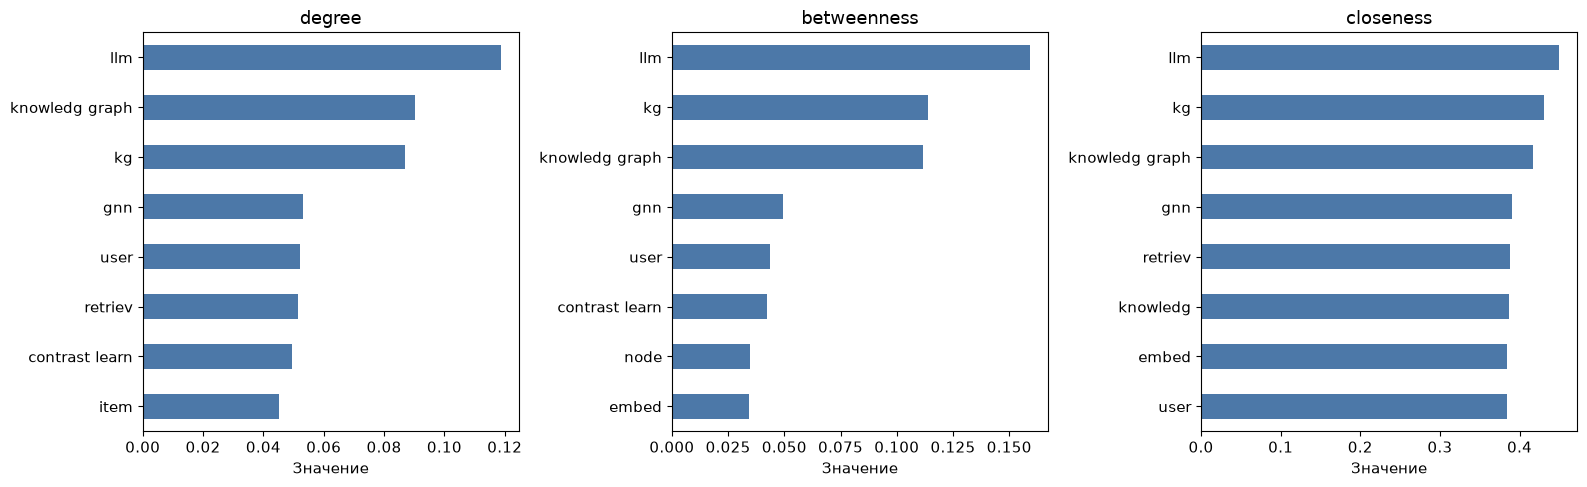

In [32]:
centralities = pd.DataFrame({
    'degree': nx.degree_centrality(G_keywords),
    'betweenness': nx.betweenness_centrality(G_keywords, weight=None),
    'closeness': nx.closeness_centrality(G_keywords, distance=None),
})

leaders = pd.DataFrame({
    metric: [f'{term} ({value:.4f})' for term, value in centralities[metric].nlargest(10).items()]
    for metric in centralities.columns
}, index=range(1, 11))
display(leaders)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, centralities.columns):
    centralities[metric].nlargest(8).sort_values().plot.barh(ax=ax, color='#4c78a8')
    ax.set(title=metric, xlabel='Значение', ylabel='')
plt.tight_layout()
plt.show()

**Интерпретация.**

- По **degree** лидирует `llm` (0,1187): он связан напрямую со 134 терминами.
  Далее идут `knowledg graph` (0,0903) и `kg` (0,0868). В этом корпусе
  языковые модели и графы знаний используются рядом с разными методами рекомендаций.
- По **betweenness** первым также является `llm` (0,1592), затем `kg`
  (0,1137) и `knowledg graph` (0,1116). Через эти термины проходит заметная
  доля кратчайших путей: они связывают разные группы слов.
- По **closeness** лидирует `llm` (0,4496), далее `kg` (0,4306) и
  `knowledg graph` (0,4172). Граф связный, поэтому значение для `llm`
  соответствует среднему расстоянию примерно 2,22 перехода до остальных терминов.

Формы `llms` и `gnns` больше не создают отдельные вершины: они приведены
к `llm` и `gnn`. При этом `kg` и `knowledg graph` не объединены как синонимы,
что влияет на распределение центральностей между ними.
Метрики характеризуют разные стороны положения вершины: число соседей,
участие в кратчайших путях и расстояние до других вершин. Совпадение лидеров
показывает заметную роль этих терминов в выбранном корпусе, но не доказывает
их объективную важность для всей научной области.


## 8. Граф публикаций и поиск похожих статей

Теперь вершина - статья с её arXiv ID. Две статьи связаны, если у них есть
хотя бы один общий ключевой термин. **Вес ребра равен числу общих терминов**:
$w(i,j)=|K_i \cap K_j|$, где $K_i$ - множество ключевых слов статьи $i$.
В графе сохраняются все статьи, включая изолированные вершины.

Простой поиск по заданной публикации: берём её соседей и сортируем по весу
ребра по убыванию. Сама статья в выдачу не попадает. При равном весе используем
порядок arXiv ID; если общих терминов нет, возвращаем пустой список.
Такое ранжирование непосредственно соответствует определению близости в задании.

**Смысл оценки поиска.** Столбец «Общих тегов» содержит целое число
от 1 до 7: значение 3 означает ровно три совпавших тега. Это вес ребра,
а не вероятность релевантности. Каждый тег учитывается один раз.
Если среди выбранных терминов были `sequenti` и `sequenti recommend`,
в итоговых тегах остаётся только `sequenti recommend`. Совпадение этой пары
теперь увеличивает вес на 1 вместо 2. Формула веса по заданию сохранена.
Общие слова и разные фразы с близким смыслом всё ещё могут давать слабые
рекомендации: число совпадений не гарантирует содержательную близость статей.

In [33]:
def publication_graph(paper_keywords):
    graph = nx.Graph()
    graph.add_nodes_from(paper_keywords)
    keyword_sets = {paper_id: set(words) for paper_id, words in paper_keywords.items()}
    for left, right in combinations(keyword_sets, 2):
        shared = keyword_sets[left] & keyword_sets[right]
        if shared:
            graph.add_edge(left, right, weight=len(shared))
    return graph

In [34]:
paper_keywords = dict(zip(df['arxiv_id'], df['keywords']))
G_papers = publication_graph(paper_keywords)
papers_by_id = df.set_index('arxiv_id')
print('Вершин:', G_papers.number_of_nodes())
print('Рёбер:', G_papers.number_of_edges())
print('Компонент связности:', nx.number_connected_components(G_papers))
print('Изолированных статей:', nx.number_of_isolates(G_papers))

Вершин: 400
Рёбер: 3232
Компонент связности: 1
Изолированных статей: 0


In [35]:
def find_similar(graph, paper_id, top_n=5):
    if paper_id not in graph:
        raise ValueError(f"Публикация {paper_id} отсутствует в корпусе")
    if top_n < 1:
        raise ValueError("top_n должен быть положительным")
    neighbors = [(node, edge["weight"]) for node, edge in graph[paper_id].items()]
    # При равных весах сортируем по arXiv ID для воспроизводимого результата.
    return sorted(neighbors, key=lambda pair: (-pair[1], pair[0]))[:top_n]

**Пользовательский запрос.** В следующей ячейке задайте `QUERY_ID` - arXiv ID
из таблицы корпуса, например значение, показанное в первой строке раздела 2.
`TOP_N` задаёт число результатов. После изменения выполните эту ячейку снова.
Рядом с найденными публикациями выводятся общие теги, объясняющие их близость.

In [36]:
QUERY_ID = df.iloc[0]['arxiv_id']  # Можно заменить строкой с ID из корпуса.
TOP_N = 5

matches = find_similar(G_papers, QUERY_ID, TOP_N)
print('Запрос:', QUERY_ID, '-', papers_by_id.at[QUERY_ID, 'title'])
print('Ключевые слова:', ', '.join(paper_keywords[QUERY_ID]))
result_rows = []
for paper_id, weight in matches:
    shared = sorted(set(paper_keywords[QUERY_ID]) & set(paper_keywords[paper_id]))
    result_rows.append({
        'arxiv_id': paper_id,
        'Название': papers_by_id.at[paper_id, 'title'],
        'Общих тегов': weight,
        'Общие теги': ', '.join(shared),
        'Ссылка': papers_by_id.at[paper_id, 'url'],
    })
if result_rows:
    display(pd.DataFrame(result_rows))
else:
    print('Статей с общими ключевыми словами не найдено.')

Запрос: 2609.31253 - Enriching Sequential Recommendation with Graph Laplacian Positional Embeddings
Ключевые слова: posit, laplacian, sequenti recommend, replac, embed, deriv


,arxiv_id,Название,Общих тегов,Общие теги,Ссылка
0,2502.15331,Lightweight yet Efficient: An External Attentive Graph Convolutional Network with Positional Prompts for S...,2,"posit, sequenti recommend",https://arxiv.org/abs/2502.15331
1,2306.10679,MB-HGCN: A Hierarchical Graph Convolutional Network for Multi-behavior Recommendation,1,embed,https://arxiv.org/abs/2306.10679
2,2309.11515,Towards Differential Privacy in Sequential Recommendation: A Noisy Graph Neural Network Approach,1,sequenti recommend,https://arxiv.org/abs/2309.11515
3,2310.03032,Graph-enhanced Optimizers for Structure-aware Recommendation Embedding Evolution,1,embed,https://arxiv.org/abs/2310.03032
4,2310.04878,Hybrid Recommendation System using Graph Neural Network and BERT Embeddings,1,embed,https://arxiv.org/abs/2310.04878


## 9. Тестирование поиска

Сначала проверим алгоритм на маленьком примере с заранее известным ответом.
У статьи A два общих тега с B и по одному с C и E; статья D изолирована.
Повтор одного слова в статье не должен увеличивать вес.
Проверим также ограничение длины выдачи, отсутствие петель, равные веса и неверный ID.

Также проверим объединение сокращений и отсутствие двойного вклада
униграммы вместе с содержащей её биграммой.
Отдельно проверяем очистку LaTeX: форматирование целого слова, отдельной буквы,
вложенные команды и знаки математического режима не меняют нормализованные слова.
Символ стрелки разделяет соседние слова, а одинаковое форматирование
двух разных тем не создаёт ребро между публикациями.


In [37]:
example = {
    "A": ["graph", "user", "item", "graph"],
    "B": ["graph", "user"],
    "C": ["graph", "knowledge"],
    "D": ["image"],
    "E": ["user"],
}
test_graph = publication_graph(example)
assert set(test_graph) == set(example), "В графе должны оставаться и изолированные статьи"
assert test_graph["A"]["B"]["weight"] == 2, "Два общих тега дают вес 2"
assert test_graph["A"]["C"]["weight"] == 1
assert not test_graph.has_edge("A", "D"), "Без общих тегов ребра нет"
assert nx.number_of_selfloops(test_graph) == 0

test_keywords = keyword_graph(example.values())
assert test_keywords["graph"]["user"]["weight"] == 2, "Повтор слова внутри статьи не увеличивает вес"
assert "image" in test_keywords and test_keywords.degree("image") == 0

assert find_similar(test_graph, "A", top_n=1) == [("B", 2)]
assert find_similar(test_graph, "A", top_n=10) == [("B", 2), ("C", 1), ("E", 1)]
assert find_similar(test_graph, "D") == [], "Для изолированной статьи результат пуст"

for paper_id, top_n in [("missing", 5), ("A", 0)]:
    try:
        find_similar(test_graph, paper_id, top_n)
    except ValueError:
        pass
    else:
        raise AssertionError("Ожидалась понятная ошибка для неверного ввода")

# Регрессии: формы сокращений и вложенные теги.
assert normalize('LLM LLMs GNN GNNs KG KGs') == 'llm llm gnn gnn kg kg'
assert normalize('patterns algorithms') == 'pattern algorithm'
assert normalize('x zz') == ''
assert remove_nested_unigrams(['knowledg', 'graph', 'knowledg graph', 'user']) == ['knowledg graph', 'user']
assert remove_nested_unigrams(['art', 'partial graph']) == ['art', 'partial graph']
clean_tags = remove_nested_unigrams(['sequenti', 'sequenti recommend'])
clean_graph = publication_graph({'A': clean_tags, 'B': clean_tags})
assert find_similar(clean_graph, 'A') == [('B', 1)], 'Вложенная униграмма не должна увеличивать вес'

# Регрессии: LaTeX не создаёт теги и не разрывает слова.
latex_examples = [
    (r'\textbf{Graph}', 'Graph'),
    (r'\textbf{G}raph', 'Graph'),
    (r'{\textbf{G}}raph', 'Graph'),
    (r'\textbf{\underline{Mob}}ility', 'Mobility'),
    (r'ro\underline{bu}st', 'robust'),
    (r'\textbf{G}raph-\textbf{A}ssisted \textbf{P}rompts', 'Graph-Assisted Prompts'),
    (r'$\textbf{Inv}$ariant $\textbf{LLM}$s', 'Invariant LLMs'),
    (r'\textit{impression} \emph{buy}', 'impression buy'),
    (r'view$\rightarrow$cart$\rightarrow$buy', 'view cart buy'),
]
for marked_up, plain in latex_examples:
    assert normalize(marked_up) == normalize(plain), f'Разметка изменила слова: {marked_up}'
latex_tag_sets = {
    'A': normalize(r'\textbf{dialogue} \emph{medication}').split(),
    'B': normalize(r'\textbf{mobility} \emph{trajectory}').split(),
}
assert publication_graph(latex_tag_sets).number_of_edges() == 0, 'Разметка не должна связывать разные темы'

print("Все проверки нормализации, графов и поиска пройдены.")

Все проверки нормализации, графов и поиска пройдены.


Затем проверим выдачу для реального корпуса: веса по убыванию, отсутствие исходной
статьи среди результатов, совпадение веса с числом общих тегов.
Покажем по три результата для нескольких разных публикаций.
Проверяем также, что команды форматирования отсутствуют в нормализованном корпусе.


In [38]:
# Команды форматирования не должны попадать в нормализованный корпус.
latex_tokens = {stemmer.stem(command) for command in ['textbf', 'textit', 'emph', 'underline']}
corpus_tokens = {word for text in normalized_texts for word in text.split()}
assert not latex_tokens & corpus_tokens, 'LaTeX-разметка осталась в текстах'

# Проверяем, что исправления применились к тегам всех публикаций.
for tags in df['keywords']:
    assert 0 < len(tags) <= TOP_KEYWORDS
    unigrams = {tag for tag in tags if ' ' not in tag}
    phrase_words = {word for tag in tags if ' ' in tag for word in tag.split()}
    assert not unigrams & phrase_words
    assert not {'llms', 'gnns', 'kgs'} & {word for tag in tags for word in tag.split()}

for query_id in df['arxiv_id']:
    found = find_similar(G_papers, query_id, top_n=5)
    weights = [weight for _, weight in found]
    assert weights == sorted(weights, reverse=True)
    assert len(found) <= 5
    assert all(other_id != query_id for other_id, _ in found)
    for other_id, weight in found:
        expected = len(set(paper_keywords[query_id]) & set(paper_keywords[other_id]))
        assert weight == expected and weight > 0
print(f'Проверка выдачи для всех {len(df)} статей пройдена.')

for position in [0, len(df) // 3, 2 * len(df) // 3]:
    query_id = df.iloc[position]['arxiv_id']
    print('\nИсходная статья:', query_id, '-', papers_by_id.at[query_id, 'title'])
    for other_id, weight in find_similar(G_papers, query_id, top_n=3):
        shared = sorted(set(paper_keywords[query_id]) & set(paper_keywords[other_id]))
        print(f'  {other_id}: {papers_by_id.at[other_id, "title"]}')
        print(f'    Вес {weight}; общие теги: {", ".join(shared)}')

Проверка выдачи для всех 400 статей пройдена.

Исходная статья: 2609.31253 - Enriching Sequential Recommendation with Graph Laplacian Positional Embeddings
  2502.15331: Lightweight yet Efficient: An External Attentive Graph Convolutional Network with Positional Prompts for Sequential Recommendation
    Вес 2; общие теги: posit, sequenti recommend
  2306.10679: MB-HGCN: A Hierarchical Graph Convolutional Network for Multi-behavior Recommendation
    Вес 1; общие теги: embed
  2309.11515: Towards Differential Privacy in Sequential Recommendation: A Noisy Graph Neural Network Approach
    Вес 1; общие теги: sequenti recommend

Исходная статья: 2506.05873 - Research on Personalized Financial Product Recommendation by Integrating Large Language Models and Graph Neural Networks
  2503.00134: Personalized Causal Graph Reasoning for LLMs: An Implementation for Dietary Recommendations
    Вес 2; общие теги: llm, person
  2305.18885: Criteria Tell You More than Ratings: Criteria Preference-Awar

**Разбор примеров.** Для статьи о позиционных представлениях в последовательных
рекомендациях (`2609.31253`) первым найден результат `2502.15331` про positional
prompts для sequential recommendation. Вес равен **2**: общие теги - `posit`
и `sequenti recommend`. Вложенная униграмма `sequenti` удалена и не увеличивает
вес повторно. Сходство названий соответствует этим двум совпадениям.
Остальные результаты имеют вес 1; общий `embed` связывает и более широкие темы.

Для статьи о финансовых продуктах и LLM (`2506.05873`) первый результат
`2503.00134` посвящён персонализированным диетическим рекомендациям с LLM.
Общие теги `llm` и `person` дают вес 2. Написание `LLMs` в найденной статье
приводится к той же форме `llm`, но совпадение метода и персонализации
не означает совпадения прикладной области: финансы и питание различаются.

Для `2406.18984` первые результаты имеют по одному общему тегу:
`amplifi`, `graph structur`, `graph learn`. Это слабые совпадения:
одно общее слово или сочетание не гарантирует одинаковую исследовательскую задачу.

Синтетические проверки подтвердили очистку LaTeX с сохранением целых слов,
объединение форм сокращений и устранение повторного вклада вложенной униграммы.
Одинаковое форматирование двух разных тем не создаёт связь между ними.
Дополнительно проверены правильные веса, порядок результатов, изолированная
вершина и неверный ввод. Проверки очистки, тегов и выдачи прошли для всех
400 статей. Граф публикаций содержит 3232 ребра, одну компоненту связности
и не содержит изолированных вершин.
Это проверка корректности алгоритма, а не независимая оценка релевантности.

## Выводы

Собран корпус публикаций по графовым рекомендательным системам, проведён анализ
текстов, проверены приближённые закономерности Ципфа и Хипса, выделены ключевые слова. На их основе построены граф терминов и граф
публикаций. Для графа терминов найдены сообщества и рассчитаны три центральности.
Реализован поиск похожих статей по общим ключевым словам; его корректность проверена
на примере с известными ответами и на всём корпусе.

Перед выделением тегов снята LaTeX-разметка с сохранением целых слов.
Команды форматирования не попадают в ключевые слова и не создают связи.
Известные формы сокращений объединены, а вложенные униграммы удалены
из тегов до построения обоих графов. Проверки подтверждают, что одна
выбранная фраза не учитывается повторно через составляющее её слово.

Ограничения: результаты зависят от поискового запроса, выбора до семи тегов
и предобработки. Очистка LaTeX учитывает перечисленные команды форматирования;
математические формулы не интерпретируются. Стемминг может объединять разные слова. Словарь сокращений
ограничен тремя семействами, а разные биграммы могут пересекаться по смыслу. Число общих тегов - простая оценка близости,
которая не учитывает синонимы и смысл аннотаций целиком. Проверки подтверждают
работу алгоритма; без независимой разметки релевантности они не измеряют
качество рекомендаций для человека.